# 02 — Confronto fra le tre pipeline

**Domanda:** A, B e C leggono gli stessi referti e producono lo stesso schema.
In che cosa differiscono davvero?

Non esiste un'annotazione manuale di riferimento — il brief la esclude — quindi
questo **non è un confronto di accuratezza contro una verità**. È uno studio di
accordo e complementarità, più un'aggiudicazione manuale su un campione, che è
l'unico modo onesto di dire qualcosa sulla precisione.

In [1]:
import sys
from pathlib import Path

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RADICE / "src"))

from confronto import *
from risolutori import RisolutoreATC

encs = sorted(p.stem for p in (RADICE / "data/processed/pipeline_b").glob("*.json")
              if not p.stem.startswith("_"))
dati = {s: carica(s, encs) for s in "ABC"}
dati["B"], ripulitura = ripulisci(dati["B"], RisolutoreATC())
print(f"record confrontati: {len(encs)}  (quanti ne ha la pipeline B, che ne ha meno)")
print(f"ripulitura di B: {ripulitura}")

record confrontati: 198  (quanti ne ha la pipeline B, che ne ha meno)
ripulitura di B: {'farmaci_riclassificati': 98, 'tenute': 5322, 'duplicati_rimossi': 427}


## 1. Perché il confronto va spezzato in due

Prima di misurare qualsiasi cosa, un controllo che ha cambiato il disegno
dell'intero step.

In [2]:
import json
def per_campo(sigla, campo, tipo=None):
    return sum(1 for ms in dati[sigla].values() for m in ms
               if m.campo == campo and (tipo is None or m.tipo == tipo))

print(f"{'':34} {'A':>7} {'B':>7} {'C':>7}")
for etichetta, campo, tipo in (
    ("condizioni dalla prosa", "Anamnesi", "condizione"),
    ("farmaci dalla prosa", "Anamnesi", "farmaco"),
    ("farmaci dalla terapia ingresso", "Terapia medica all'ingresso", None),
    ("farmaci dalla terapia dimissione", "Terapia alla Dimissione", None),
):
    print(f"{etichetta:34}" + "".join(f"{per_campo(s, campo, tipo):7}" for s in "ABC"))

                                         A       B       C
condizioni dalla prosa               1075   3474   1112
farmaci dalla prosa                   529     35    588
farmaci dalla terapia ingresso       1118   1257   1118
farmaci dalla terapia dimissione     1317    556   1317


**Cosa se ne deduce.** Sui due campi di terapia **A e C danno numeri identici**,
perché usano lo stesso parser deterministico: confrontarli lì misurerebbe zero
per costruzione. La pipeline B invece li fa leggere al modello.

Il confronto va quindi spezzato in due domande diverse:

1. **Sulla prosa** — le tre pipeline riconoscono davvero cose diverse. È qui che
   si misura il riconoscimento.
2. **Sui campi strutturati** — il parser fa da riferimento affidabile, e la
   domanda diventa: *un modello linguistico regge il confronto con quaranta
   righe di regex su un campo semi-strutturato?*

## 2. Come si decide che due menzioni sono la stessa

Stesso ricovero, stesso campo, intervalli di caratteri che si sovrappongono. È
l'unico criterio che non dipende da come ciascuna pipeline sceglie i confini —
il gazetteer aggancia il termine di vocabolario, il NER l'estensione appresa,
il modello spesso la frase intera.

Le menzioni collegate formano un grafo, e ogni componente connessa è un «punto»
del referto. Le componenti in cui una pipeline mette più di una menzione sono
**ambigue** e vengono escluse dai confronti attributo per attributo, invece di
essere risolte a forza.

In [3]:
prosa = raggruppa([m for s in "ABC" for ms in dati[s].values()
                   if True for m in ms if m.campo == CAMPO_PROSA])
v = venn(prosa)
print(f"punti distinti nella prosa: {len(prosa)}  ·  ambigui: {sum(1 for g in prosa if g.ambiguo)}\n")
for chiave in ("ABC", "AC", "BC", "AB", "A", "B", "C"):
    if v.get(chiave):
        print(f"  viste da {chiave:4} {v[chiave]:6}")

punti distinti nella prosa: 4267  ·  ambigui: 147

  viste da ABC     761
  viste da AC      740
  viste da BC       34
  viste da AB       14
  viste da A        26
  viste da B      2616
  viste da C        76


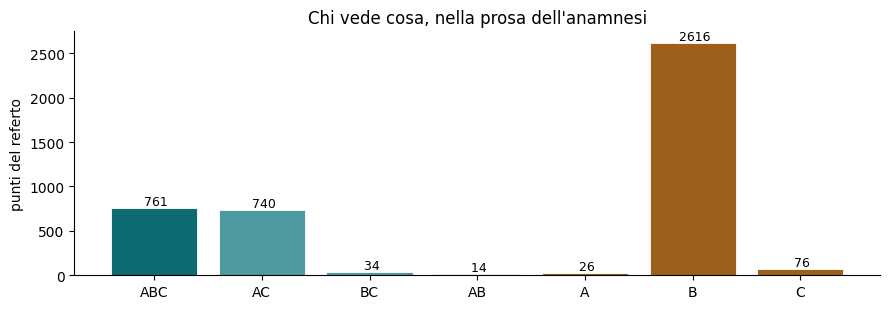

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

etichette = ["ABC", "AC", "BC", "AB", "A", "B", "C"]
valori = [v.get(k, 0) for k in etichette]
colori = ["#0d6a72" if len(k) == 3 else ("#4f9aa0" if len(k) == 2 else "#9c5f1c")
          for k in etichette]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(etichette, valori, color=colori, edgecolor="white", linewidth=.6)
for x, y in zip(etichette, valori):
    ax.text(x, y, f" {y}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("punti del referto")
ax.set_title("Chi vede cosa, nella prosa dell'anamnesi")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Cosa se ne deduce.** A e C si sovrappongono quasi del tutto: 1 501 punti
condivisi contro 26 e 76 esclusivi. Il NER è addestrato sull'uscita del
gazetteer, quindi era atteso — ma le poche differenze sono le più interessanti,
come si vede più sotto.

La pipeline B vive in un mondo a parte: **2 616 punti che nessun'altra vede**.
Questo numero da solo non dice niente. Potrebbe essere richiamo eccezionale o
rumore massiccio, e distinguere le due cose richiede di guardare.

## 3. L'aggiudicazione: leggere le menzioni una per una

Le menzioni trovate da una sola pipeline sono state estratte, lette **nel loro
referto** e giudicate a mano: la menzione individua un'entità clinica reale, sì
o no? Tutte e 26 quelle di A, un campione casuale di 25 di C e 30 di B.

I verdetti sono registrati qui sotto in modo che chiunque possa rileggerli.

In [5]:
import random

# 1 = entita' clinica reale, correttamente individuata; 0 = no.
# Assegnati leggendo ciascuna menzione nel referto di provenienza.
VERDETTI = {
 "A": [0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,1,1,0,0,0,1,0,0,1,1,1],
 "C": [1,1,0,1,0,0,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1],
 "B": [1,1,1,0,1,1,0,0,1,1,1,1,0,0,0,1,1,1,0,1,1,0,1,0,1,1,0,0,0,0],
}
random.seed(11)   # lo stesso seme del campionamento originale
campioni = {"A": solo_di(prosa, "A"),
            "C": random.sample(solo_di(prosa, "C"), 25),
            "B": random.sample(solo_di(prosa, "B"), 30)}

print(f"{'':4} {'campione':>9} {'corrette':>9} {'precisione':>11} {'errori CON codice':>19}")
for s in "ACB":
    verdetti, menzioni = VERDETTI[s], campioni[s]
    errori = [m for m, ok in zip(menzioni, verdetti) if not ok]
    codificati = sum(1 for m in errori if m.codice)
    print(f"{s:4} {len(verdetti):9} {sum(verdetti):9} {sum(verdetti)/len(verdetti):10.1%}"
          f" {codificati:9}/{len(errori):<3} ({codificati/len(errori) if errori else 0:.0%})")

      campione  corrette  precisione   errori CON codice
A           26        14      53.8%        12/12  (100%)
C           25        18      72.0%         0/7   (0%)
B           30        17      56.7%         0/13  (0%)


**Cosa se ne deduce, ed è il risultato centrale di questo step.**

Le tre precisioni sono vicine — 54%, 72%, 57% — ma l'ultima colonna dice una
cosa completamente diversa: **tutti gli errori esclusivi di A portano con sé un
codice ICD assegnato con sicurezza; nessuno di quelli di B e C ce l'ha.**

La ragione è strutturale. Il gazetteer di A **riconosce e codifica in un unico
passo**: se una forma ha fatto match, il codice c'è per costruzione. B e C
riconoscono prima e collegano dopo, quindi un riconoscimento sbagliato di norma
non aggancia nulla e resta visibile come irrisolto.

In [6]:
for s in "ACB":
    errori = [m for m, ok in zip(campioni[s], VERDETTI[s]) if not ok and m.codice]
    if not errori:
        print(f"{s}: nessun errore codificato\n")
        continue
    print(f"{s}: errori che hanno comunque ricevuto un codice")
    for m in errori:
        print(f"    {m.codice:9} «{m.testo[:52]}»")
    print()

A: errori che hanno comunque ricevuto un codice
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    S26       «del Cuore»
    S26       «del cuore»
    M67.4     «ganglio»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    S26       «del cuore»
    Z29.0     «isolamento»
    Z29.0     «isolamento»

C: nessun errore codificato

B: nessun errore codificato



Guardando i casi, l'errore non è casuale ma **sistematico**: `isolamento`
riceve `Z29.0`, che nell'ICD significa *isolamento profilattico*. Nei referti
quella parola compare quasi sempre in due sensi diversi — «isolamento di germi»
in una coltura, e «isolamento elettrico delle vene polmonari», che è una
procedura di ablazione. Nessuno dei due è isolamento profilattico.

Allo stesso modo `del cuore` riceve `S26` (*trauma cardiaco*) dalla frase
«Ospedale del Cuore».

Per il filtro di sicurezza dello step 8 questa è la distinzione che conta più di
qualunque punto percentuale: **un errore che porta un codice verrà usato; uno
che resta irrisolto si vede.**

## 4. Dove le pipeline concordano

Sui punti che due pipeline hanno visto entrambe, quanto concordano sugli
attributi? Solo sui gruppi non ambigui, per la ragione della sezione 2.

In [7]:
print(f"{'coppia':8} {'attributo':11} {'confrontabili':>13} {'accordo':>9}")
for a, b in (("A","C"), ("A","B"), ("B","C")):
    for att in ("stato", "soggetto", "codice"):
        r = accordo(prosa, a, b, att)
        print(f"{a}-{b:6} {att:11} {r['confrontabili']:13} {r['quota_accordo']:8.1%}")
    print()

coppia   attributo   confrontabili   accordo
A-C      stato                1404   100.0%
A-C      soggetto             1404   100.0%
A-C      codice               1404    99.2%

A-B      stato                 683    94.6%
A-B      soggetto              683   100.0%
A-B      codice                683    90.5%

B-C      stato                 700    94.4%
B-C      soggetto              700   100.0%
B-C      codice                700    90.3%



**Cosa se ne deduce.**

L'accordo **A-C sullo stato clinico è del 100%**, e non è un risultato: le due
pipeline usano *la stessa* implementazione di ConText, quindi non potevano che
concordare. È un controllo di sanità che è passato.

Il numero informativo è **A-B al 94,6%**, perché lì due metodi diversi arrivano
alla stessa conclusione nel 95% dei casi. Il **soggetto concorda al 100% in
tutte le coppie**: anche quello è per costruzione — l'asse *experiencer* è
calcolato dalla stessa funzione condivisa — ma dice che la regola è stabile
rispetto ai confini della menzione, che invece sono diversi fra pipeline.

## 5. Un LLM contro un parser, sul campo semi-strutturato

Qui il parser deterministico fa da riferimento: sui campi di terapia interpreta
il 99% delle voci, misurato allo step 0.

In [8]:
for campo in ("Terapia medica all'ingresso", "Terapia alla Dimissione"):
    g = raggruppa([m for s in "ABC" for ms in dati[s].values() for m in ms
                   if m.campo == campo])
    vv = venn(g)
    trovate = vv.get("ABC",0) + vv.get("AB",0) + vv.get("BC",0)
    perse   = vv.get("AC",0)  + vv.get("A",0)  + vv.get("C",0)
    print(f"{campo}")
    print(f"    voci del parser {trovate+perse:5}  ·  ritrovate da B {trovate:5} "
          f"({trovate/(trovate+perse):5.1%})  ·  solo di B {vv.get('B',0)}")

Terapia medica all'ingresso
    voci del parser  1099  ·  ritrovate da B  1017 (92.5%)  ·  solo di B 75
Terapia alla Dimissione
    voci del parser  1310  ·  ritrovate da B   423 (32.3%)  ·  solo di B 17


In [9]:
from collections import Counter
dist = Counter()
for e in encs:
    rif = sum(1 for m in dati["A"][int(e)] if m.campo == "Terapia alla Dimissione")
    tro = sum(1 for m in dati["B"][int(e)] if m.campo == "Terapia alla Dimissione")
    if not rif: continue
    dist["nessuna (0%)" if tro == 0 else
         ("tutte o quasi (>=100%)" if tro >= rif else "parziale")] += 1
print("recupero di B sulla terapia di dimissione, record per record:")
for k, n in dist.most_common():
    print(f"    {k:24} {n:4} record")

recupero di B sulla terapia di dimissione, record per record:
    nessuna (0%)               96 record
    tutte o quasi (>=100%)     58 record
    parziale                   11 record


**Cosa se ne deduce.** L'asimmetria è enorme: **92,5% sulla terapia
all'ingresso, 32,3% su quella di dimissione**, con lo stesso modello, lo stesso
prompt e campi altrettanto regolari.

E la distribuzione non è graduale ma **bimodale**: su 96 record il modello non
estrae *nessuna* voce di dimissione, su 58 le estrae tutte. O legge il campo o
lo salta.

Ho cercato una discriminante — lunghezza del referto, numero di condizioni
estratte prima, numero di voci da estrarre — e **non ce n'è una misurabile**: i
due gruppi si somigliano. Il comportamento è semplicemente incoerente, ed è
questa la conclusione: su un campo che una regex interpreta al 99%, un modello
da quattro miliardi di parametri lo interpreta al 32% **senza che si possa
prevedere quando**.

## 6. Che cosa se ne porta via il progetto

| | pipeline A | pipeline B | pipeline C |
|---|---|---|---|
| punti esclusivi nella prosa | 26 | 2 616 | 76 |
| precisione sul campione aggiudicato | 53,8% | 56,7% | **72,0%** |
| **errori che portano un codice** | **100%** | 0% | 0% |
| copertura ICD sulle condizioni | 99,9% | 28,4% | 94,0% |
| recupero sulla terapia di dimissione | riferimento | 32,3% | riferimento |
| tempo per record | 0,02 s | 267 s | 0,46 s |

**Non c'è una pipeline che vince.** Ci sono tre profili di errore diversi, e per
il motore di raccomandazione conta più il profilo del punteggio:

* **A** è velocissima e ha la copertura più alta, ma la copertura è alta *per
  costruzione* — il suo vocabolario è fatto di termini ICD, quindi tutto ciò che
  trova è codificabile per definizione. In compenso **i suoi errori sono già
  codificati**, e sono quelli che il filtro di sicurezza userebbe senza
  accorgersene.
* **C** ha la precisione migliore sulle menzioni esclusive e i suoi errori sono
  quasi tutti di confine (`re` da *remdesivir*, `gli` da *glifozina*) —
  visibili, non codificati, correggibili.
* **B** trova moltissimo, ma un terzo delle sue condizioni sono narrazione
  scambiata per diagnosi, e sul campo strutturato è inaffidabile in modo
  imprevedibile.

L'uso sensato è **insieme**: il gazetteer per codificare, il NER per segnalare
ciò che alla knowledge base manca, il modello per la comprensione contestuale
dove serve — e mai il modello dove basta una regex.